In [160]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

In [161]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [162]:
train_data.shape, train_labels.shape

((60000, 28, 28), (60000,))

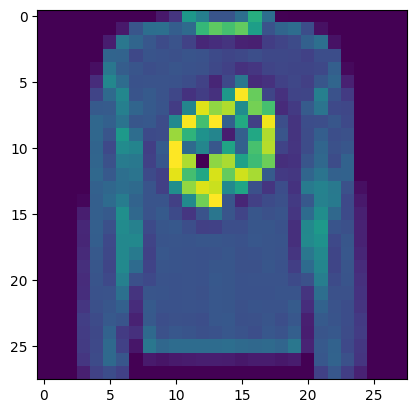

In [ ]:
# plot a single example
import matplotlib.pyplot as plt

plt.imshow(train_data[123])

plt.show()

In [ ]:
classnames = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

len(classnames)

10

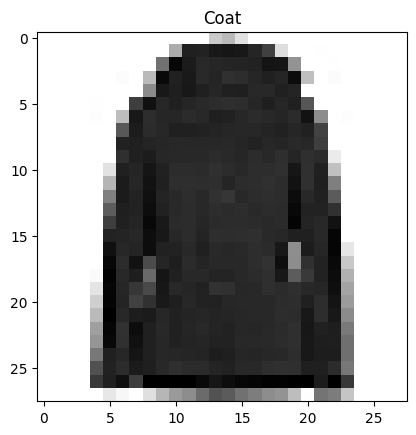

In [165]:
index = 2000

plt.imshow(train_data[index], cmap=plt.cm.binary)
plt.title(classnames[train_labels[index]])
plt.show()

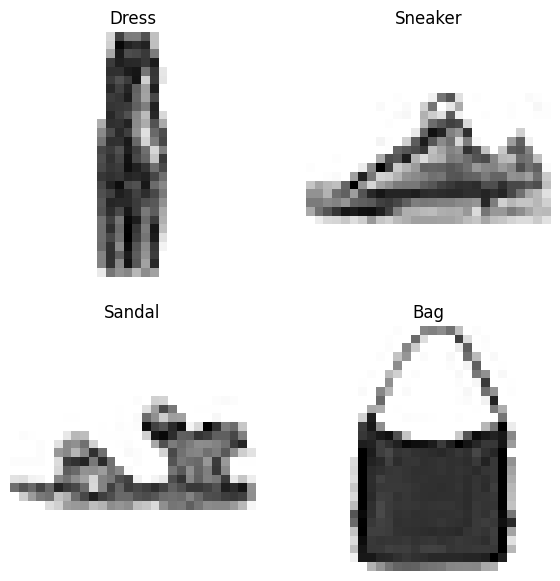

In [ ]:
# plot multiple random images

import random

plt.figure(figsize=(7, 7))

for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    rand_index = random.choice(range(len(train_data)))
    plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
    plt.title(classnames[train_labels[rand_index]])
    plt.axis("off")

plt.show()

# Normalizing the data

Currently images pixels range from (0 - 255), normalize that to (0-1)
Without this, model performs very poorly


In [167]:
train_data = train_data / 255.0
test_data = test_data / 255.0

## Building multiclass classification problem

Input Shape: 28x28

Output Shape: 1x10 (because we have 10 classes)
Output layer activation = Softmax


In [ ]:
tf.random.set_seed(42)
import warnings

warnings.filterwarnings("ignore")

model1 = tf.keras.Sequential(
    [
        # Out input shape is (60000, 28, 28), we don't need to tell how many samples we have, so we remove the first dimension and only specify the shape of a single sample (28, 28)
        tf.keras.layers.Input(shape=train_data.shape[-2:]),
        # (somevalue, 28, 28) will be turned into (somevalue, 784) 28*28=784
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(4, activation="relu"),
        tf.keras.layers.Dense(4, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

In [ ]:
# if labels are one hot encoded use this loss function: CategoricalCrossentropy
# if labels are as integers use SparseCategoricalCrossentropy

model1.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [170]:
history1 = model1.fit(
    train_data,
    train_labels,
    epochs=10,
    validation_data=(test_data, test_labels),
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5810 - loss: 1.1684 - val_accuracy: 0.7167 - val_loss: 0.8242
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7511 - loss: 0.7162 - val_accuracy: 0.7734 - val_loss: 0.6656
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7849 - loss: 0.6220 - val_accuracy: 0.7875 - val_loss: 0.6200
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7958 - loss: 0.5889 - val_accuracy: 0.7936 - val_loss: 0.6012
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8025 - loss: 0.5705 - val_accuracy: 0.7988 - val_loss: 0.5881
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8067 - loss: 0.5583 - val_accuracy: 0.8018 - val_loss: 0.5778
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8098 - loss: 0.5493 - val_accuracy: 0.8032 - val_loss: 0.5731
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8120 - loss: 0.5423 - 

### If you want to use CategoricalCrossEntropy OneHotEncode the training and testing labels


In [ ]:
model2 = tf.keras.models.clone_model(model1)

model2.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [ ]:
history2 = model2.fit(
    train_data,
    tf.one_hot(train_labels, depth=10),
    epochs=10,
    validation_data=(test_data, tf.one_hot(test_labels, depth=10)),
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5136 - loss: 1.2684 - val_accuracy: 0.6989 - val_loss: 0.8480
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7418 - loss: 0.7587 - val_accuracy: 0.7616 - val_loss: 0.7077
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7695 - loss: 0.6739 - val_accuracy: 0.7702 - val_loss: 0.6748
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7767 - loss: 0.6470 - val_accuracy: 0.7735 - val_loss: 0.6610
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7816 - loss: 0.6322 - val_accuracy: 0.7780 - val_loss: 0.6529
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7848 - loss: 0.6219 - val_accuracy: 0.7804 - val_loss: 0.6466
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7877 - loss: 0.6142 - val_accuracy: 0.7831 - val_loss: 0.6424
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7897 - loss: 0.6081 - 

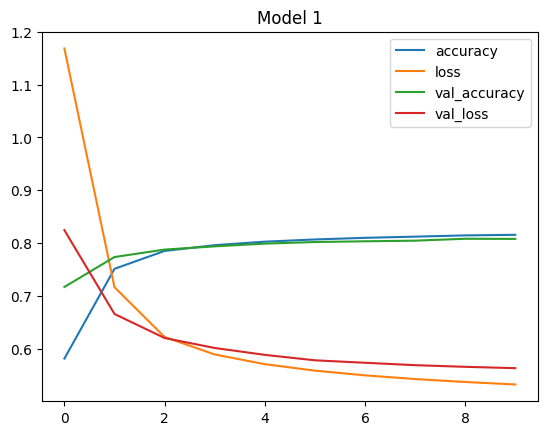

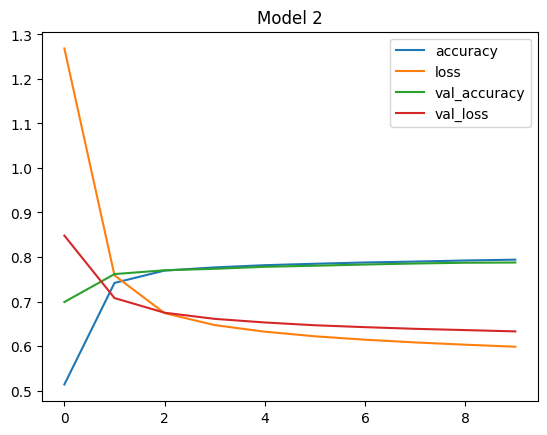

In [173]:
import pandas as pd

pd.DataFrame(history1.history).plot(title="Model 1")
pd.DataFrame(history2.history).plot(title="Model 2")

plt.show()

**NOTE** _For comparing models_

The same model with even slightly different data can produce dramatically different results. So when you're comparing models, it's important to make sure you're comparing them on the same criteria (e.g. same architecture but different data or same data but different architecture)


## Finding the IDEAL learning rate


In [ ]:
tf.random.set_seed(42)

model3 = tf.keras.Sequential(
    [
        # Out input shape is (60000, 28, 28), we don't need to tell how many samples we have, so we remove the first dimension and only specify the shape of a single sample (28, 28)
        tf.keras.layers.Input(shape=train_data.shape[-2:]),
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(4, activation="relu"),
        tf.keras.layers.Dense(4, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

In [175]:
model3.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [ ]:
# start at 10^-3, then at every epoch increase 18^(epoch/20)
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-3 * 10 ** (epoch / 20)
)

In [ ]:
history3 = model3.fit(
    train_data,
    train_labels,
    epochs=40,
    validation_data=(test_data, test_labels),
    callbacks=[lr_scheduler],
)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5024 - loss: 1.3091 - val_accuracy: 0.6338 - val_loss: 0.9341 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6660 - loss: 0.8546 - val_accuracy: 0.7136 - val_loss: 0.7902 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7258 - loss: 0.7305 - val_accuracy: 0.7253 - val_loss: 0.7181 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7345 - loss: 0.6882 - val_accuracy: 0.7301 - val_loss: 0.6929 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7389 - loss: 0.6673 - val_accuracy: 0.7357 - val_loss: 0.6793 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7469 - loss: 0.6548 - val_accuracy: 0.7445 - val_loss: 0.6692 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7554 - l

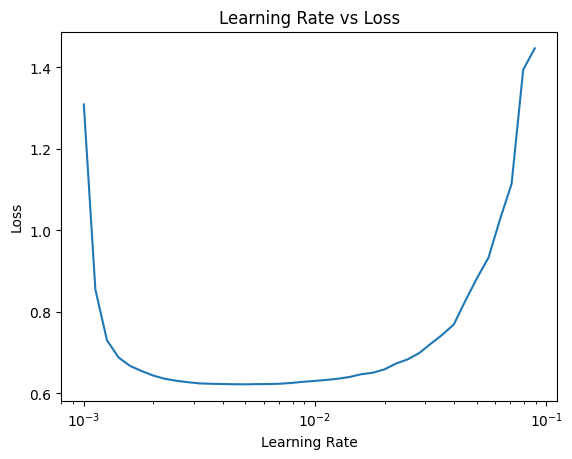

In [ ]:
# plot the learning rate decay
import numpy as np

test_epochs = 10

lrs = 1e-3 * (10 ** (tf.range(40) / 20))

plt.semilogx(lrs, history3.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss")
plt.show()

## Training the model again with IDEAL learning rate that is between $10^{-3}$ and $10^{-2}$ that is $0.0055$


In [ ]:
tf.random.set_seed(42)

model4 = tf.keras.Sequential(
    [
        # Out input shape is (60000, 28, 28), we don't need to tell how many samples we have, so we remove the first dimension and only specify the shape of a single sample (28, 28)
        tf.keras.layers.Input(shape=train_data.shape[-2:]),
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(4, activation="relu"),
        tf.keras.layers.Dense(4, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

In [180]:
model4.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0055),
    metrics=["accuracy"],
)

In [181]:
history4 = model4.fit(
    train_data,
    train_labels,
    epochs=20,
    validation_data=(test_data, test_labels),
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5453 - loss: 1.1061 - val_accuracy: 0.6283 - val_loss: 0.9028
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6414 - loss: 0.8581 - val_accuracy: 0.6532 - val_loss: 0.8524
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6586 - loss: 0.8236 - val_accuracy: 0.6698 - val_loss: 0.8327
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6701 - loss: 0.8074 - val_accuracy: 0.6811 - val_loss: 0.8216
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6756 - loss: 0.7982 - val_accuracy: 0.6733 - val_loss: 0.8188
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6799 - loss: 0.7919 - val_accuracy: 0.6835 - val_loss: 0.8116
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7187 - loss: 0.7604 - val_accuracy: 0.7139 - val_loss: 0.7743
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7301 - loss: 0.7392 - 

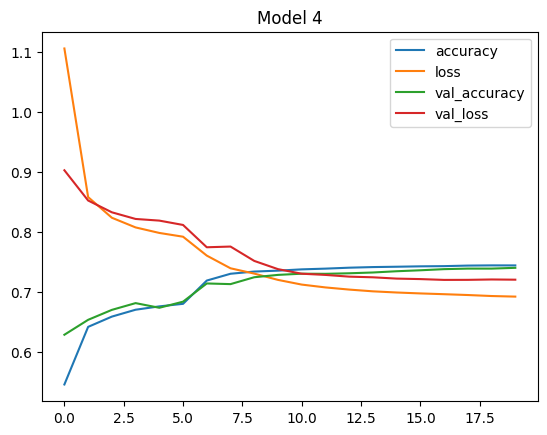

In [182]:
pd.DataFrame(history4.history).plot(title="Model 4")
plt.show()

## Evaluating the Model


In [ ]:
# confusion matrix
import itertools
from sklearn.metrics import confusion_matrix


def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    n_classes = cm.shape[0]

    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)

    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])

    # lable the axes
    ax.set(
        title="Confusion Matrix",
        xlabel="Predicted Label",
        ylabel="True Label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels,
    )

    # set the x-axis labels to bottom
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()

    # Adjust the label size
    ax.yaxis.label.set_size(text_size)
    ax.xaxis.label.set_size(text_size)
    ax.title.set_size(text_size)

    # set the threshold for different colors
    threshold = (cm.max() + cm.min()) / 2.0

    # plot the text on each cell
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j,
            i,
            f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
            horizontalalignment="center",
            color="white" if cm[i, j] > threshold else "black",
            size=text_size,
        )

    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


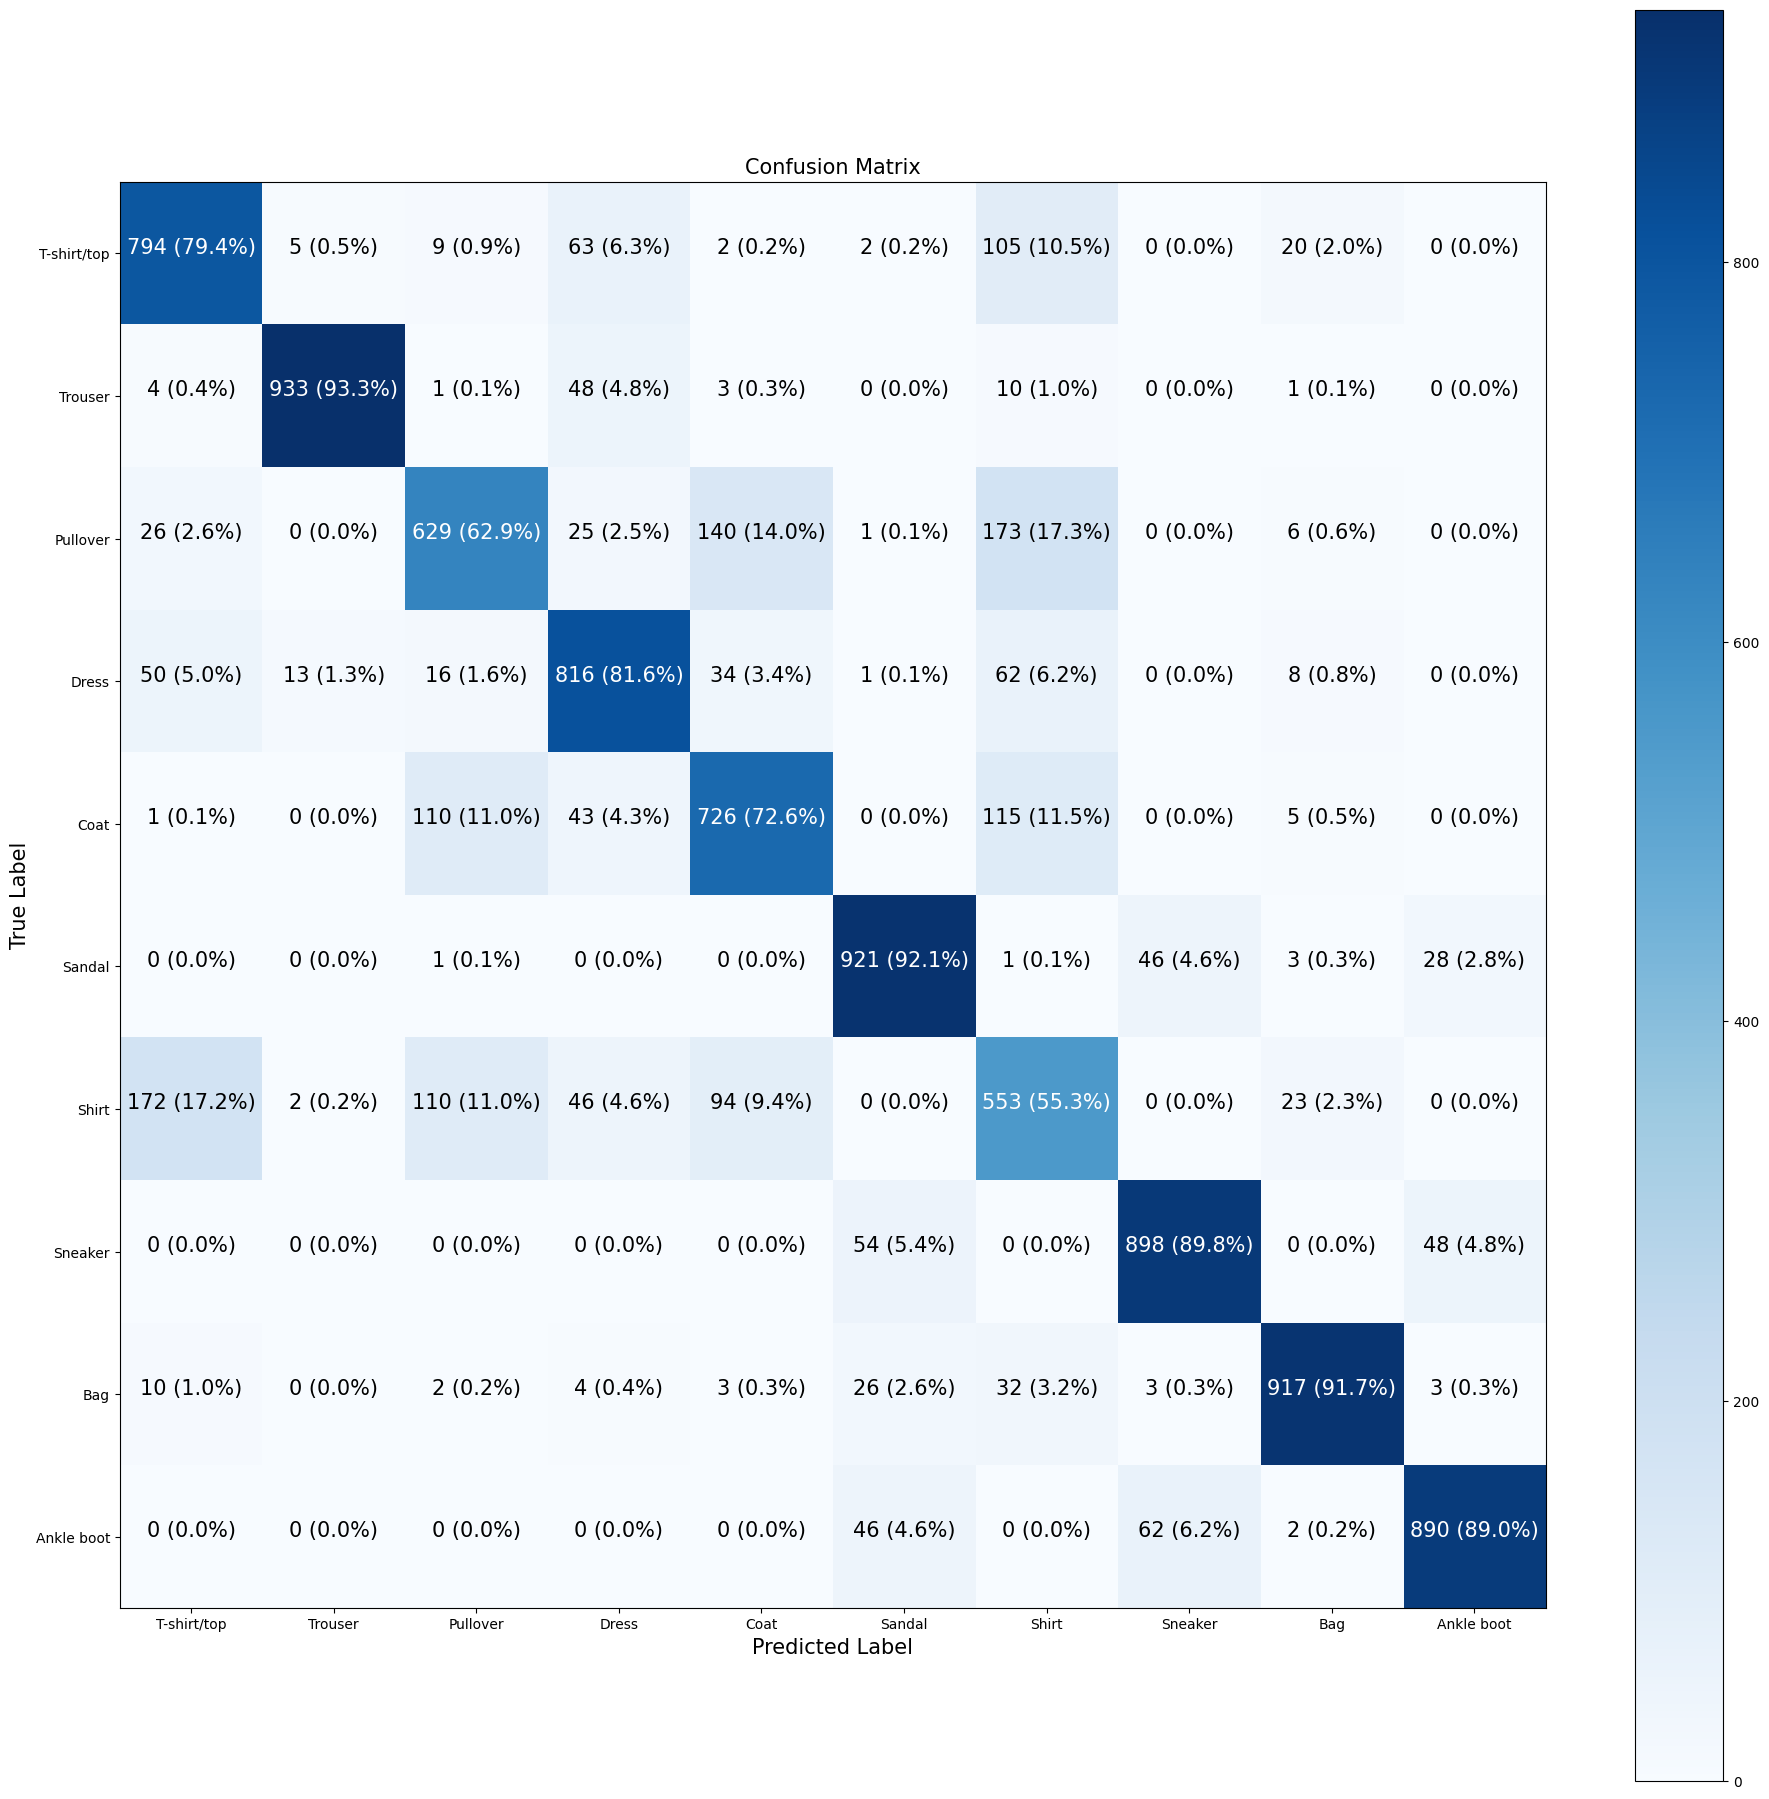

In [ ]:
make_confusion_matrix(
    test_labels,
    tf.argmax(model1.predict(test_data), axis=1),
    figsize=(23, 23),
    classes=classnames,
)

## Create a function for:

- Plot a random image
- Make prediction on said image
- Label the plot with the truth label & the predicted label


In [ ]:
import random


def plot_random_image(model, images, true_labels, classes):
    """
    Picks a random image, plots it and label it with a prediction and truth label.
    """
    i = random.randint(0, len(images))

    # Create a prediction and target
    target_image = images[i]
    pred_probs = model.predict(target_image.reshape(1, 28, 28))
    pred_label = classes[pred_probs.argmax()]
    true_label = classes[true_labels[i]]

    # plot the image
    plt.imshow(target_image, cmap=plt.cm.binary)
    plt.title(
        f"Pred: {pred_label} | Truth: {true_label} | {100*np.max(pred_probs):.2f}%",
        color="green" if pred_label == true_label else "red",
    )  # tf.reduce_max == np.max
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


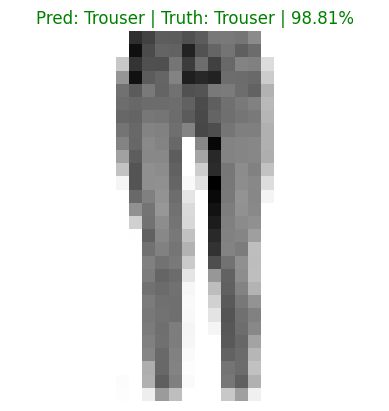

In [ ]:
plot_random_image(
    model=model1,
    images=test_data,
    true_labels=test_labels,
    classes=classnames,
)  # can work on both train and test data